In [1]:
%matplotlib widget

# Bayesian analysis

The previous tutorials demonstrate how to obtain *maximum-likelihood* estimates of the parameters of a model by minimising $\chi^2$.
An alternative, and often more informative, view of the same problem is provided by a **Bayesian** analysis, in which the goal is to characterise the full *posterior distribution* over the parameters given the data.

Recall Bayes' theorem,

$$
p(\theta \mid d) \propto p(d \mid \theta)\, p(\theta),
$$ (bayes)

where $\theta$ are the model parameters, $d$ is the observed data, $p(d \mid \theta)$ is the likelihood, and $p(\theta)$ is the prior. In `easyscience`, the `min`/`max` bounds of a `Parameter` are interpreted as a **uniform prior**, and a Gaussian likelihood is constructed from the data and supplied weights.

`easyscience` exposes a Bayesian Markov-chain Monte Carlo (MCMC) sampler through the `MultiFitter.sample` method.  Under the hood this uses BUMPS' DREAM sampler, so the underlying minimizer must be switched to BUMPS.

### When should you use a Bayesian analysis?

A maximum-likelihood estimate (MLE) gives you a single best-fit value with a symmetric uncertainty, which is fast and often sufficient. A Bayesian analysis becomes valuable when:

- **Your uncertainties are asymmetric** &mdash; MLE error bars assume the parameter distribution is Gaussian, which is not always true. The posterior samples capture skew naturally.
- **You have prior knowledge** &mdash; if you know from physics that a parameter *must* lie in a certain range, encoding that as a prior ($p(\theta)$) is more principled than simply clamping bounds after the fit.
- **You care about parameter correlations** &mdash; the joint posterior (Exercise 6) reveals trade-offs between parameters that a single covariance matrix can miss.
- **You want to propagate uncertainty to predictions** &mdash; with the posterior in hand, you can compute credible bands on any function of the parameters (Exercise 7) without linearised error propagation.

The trade-off is computational cost: MCMC requires thousands of model evaluations, whereas an MLE fit may converge in dozens. For the simple 4-parameter model used here the difference is negligible, but for expensive models it is worth starting with MLE and only switching to MCMC when you need the richer output.

In this tutorial we re-use the QENS dataset and the Lorentzian-with-resolution model from the [Fitting QENS](fitting-qens.ipynb) tutorial, but instead of returning a single best-fit value with a symmetric error bar we will draw thousands of samples from the posterior.

## Load the data

We load the same simulated QENS dataset that was used in the previous tutorial.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def fetch_data(name: str) -> str:
    """
    Fetch pre-prepared data from a remote source and return the path to the file.
    """
    import pooch

    return pooch.retrieve(
        url=f'https://public.esss.dk/groups/scipp/dmsc-summer-school/2025/{name}',
        known_hash=None,
    )

In [4]:
filename = fetch_data('4-reduction/energy_transfer_QENS_unknown_quasi_elastic_many_neutrons.dat')


def load(filename: str):
    """Load data from file and filter NaN values."""
    x, y, e = np.loadtxt(filename, unpack=True)
    sel = np.isfinite(y)
    return x[sel], y[sel], e[sel]


omega, intensity_obs, di = load(filename)

# Restrict to the region of interest, as in the QENS tutorial.
sel = (omega > -0.06) & (omega < 0.06)
omega, intensity_obs, di = omega[sel], intensity_obs[sel], di[sel]

SHA256 hash of downloaded file: e49fa9a1d2ef5eeb714524903e8ffa9de6616e5a299a799cbb0b2f3ee8fd459a
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


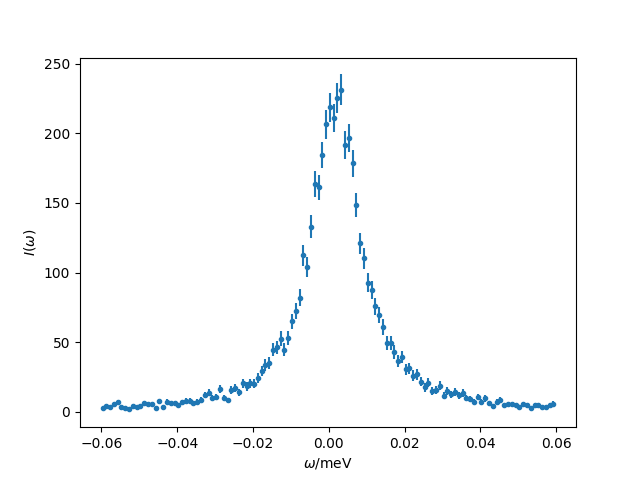

In [5]:
fig, ax = plt.subplots()
ax.errorbar(omega, intensity_obs, di, fmt='.')
ax.set(xlabel='$\\omega$/meV', ylabel='$I(\\omega)$')
plt.show()

## The model

We re-use the convolution of a Lorentzian with a Gaussian resolution function from the QENS tutorial:

$$
I(\omega) = \frac{A\gamma}{\pi\big[(\omega - \omega_0)^2 + \gamma^2\big]} \;\ast\; \mathcal{N}(0, \sigma),
$$ (model)

where $A$ is a scale factor, $\gamma$ is the Lorentzian half-width at half-maximum, $\omega_0$ is the centre offset and $\sigma$ is the width of the Gaussian resolution kernel.

```{note}
The convolution below uses `np.convolve(..., 'same')` for simplicity. In `'same'` mode, `numpy` pads the signal edges with zeros, which can introduce small artefacts at the boundaries. Because our Gaussian kernel ($\sigma \approx 10^{-3}$) is much narrower than the data range ($\pm 0.06$ meV), these edge effects are negligible here. For production work with broader kernels, consider `scipy.signal.convolve` with an explicit boundary mode such as `'reflect'` or `'nearest'`.
```

In [6]:
from scipy.stats import norm


def lorentzian(x: np.ndarray) -> np.ndarray:
    return A.value / np.pi * gamma.value / ((x - omega_0.value) ** 2 + gamma.value**2)


def intensity(x: np.ndarray) -> np.ndarray:
    gauss = norm(0, sigma.value).pdf(x)
    gauss /= gauss.sum()
    return np.convolve(lorentzian(x), gauss, 'same')

## Exercise 1: parameters with priors

Create four `Parameter` objects, for $A$, $\gamma$, $\omega_0$ and $\sigma$. The `min` and `max` arguments define a **uniform prior** on each parameter &mdash; the sampler will only consider values inside this range and will treat every value inside the range as equally plausible *a priori*.

| Parameter | Initial Value | Min | Max |
| --- | --- | --- | --- |
| $A$ | 10 | 1 | 100 |
| $\gamma$ | 8.0 &times; 10<sup>-3</sup> | 1.0 &times; 10<sup>-4</sup> | 1.0 &times; 10<sup>-2</sup> |
| $\omega_0$ | 1.0 &times; 10<sup>-3</sup> | 0 | 2.0 &times; 10<sup>-3</sup> |
| $\sigma$ | 1.0 &times; 10<sup>-3</sup> | 1.0 &times; 10<sup>-5</sup> | 1.0 &times; 10<sup>-1</sup> |

**Solution:**

In [7]:
from easyscience import Parameter

A = Parameter(name='A', value=10, fixed=False, min=1, max=100)
gamma = Parameter(name='gamma', value=8e-3, fixed=False, min=1e-4, max=1e-2)
omega_0 = Parameter(name='omega_0', value=1e-3, fixed=False, min=0, max=2e-3)
sigma = Parameter(name='sigma', value=1e-3, fixed=False, min=1e-5, max=1e-1)

## Exercise 2: maximum-likelihood fit (for reference)

Before running MCMC, perform a quick maximum-likelihood fit. The result will give us a good starting point and lets us compare the central tendency of the posterior with the classical best-fit values.

**Solution:**

In [8]:
from easyscience import Fitter
from easyscience import ObjBase

params = ObjBase(name='params', A=A, gamma=gamma, omega_0=omega_0, sigma=sigma)

mle_fitter = Fitter(params, intensity)
mle_result = mle_fitter.fit(x=omega, y=intensity_obs, weights=1 / di)

A, gamma, omega_0, sigma

/tmp/ipykernel_2457/583337586.py:4: DeprecationWarning: ObjBase is deprecated and will be removed in a future version. Please migrate to ModelBase.
  params = ObjBase(name='params', A=A, gamma=gamma, omega_0=omega_0, sigma=sigma)


(<Parameter 'A': 5.2266 ± 0.0498, bounds=[1.0:100.0]>,
 <Parameter 'gamma': 0.0072 ± 0.0001, bounds=[0.0001:0.01]>,
 <Parameter 'omega_0': 0.0011 ± 0.0001, bounds=[0.0:0.002]>,
 <Parameter 'sigma': 0.0011 ± 0.0006, bounds=[1e-05:0.1]>)

## Exercise 3: switch to BUMPS and draw posterior samples

`MultiFitter.sample` exposes the BUMPS DREAM sampler. It accepts a list of datasets (one entry per model) and returns a dictionary with the following keys:

- `draws`: a `(n_samples, n_parameters)` array of posterior samples;
- `param_names`: the unique names of the parameters, in the same column order as `draws`;
- `state`: the underlying BUMPS `MCMCDraw` object, useful for advanced diagnostics;
- `logp`: the log-posterior of each retained sample.

DREAM only works with the BUMPS minimizer, so the first step is to switch the minimizer over.

**Solution:**

In [9]:
from easyscience import AvailableMinimizers
from easyscience.fitting.multi_fitter import MultiFitter

sampler = MultiFitter([params], [intensity])
sampler.switch_minimizer(AvailableMinimizers.Bumps)

result = sampler.sample(
    x=[omega],
    y=[intensity_obs],
    weights=[1 / di],
    samples=4000,
    burn=500,
    thin=2,
    seed=42,
)

print(f'Drew {result["draws"].shape[0]} samples for {result["draws"].shape[1]} parameters.')
print('parameters:', result['param_names'])

Drew 1000 samples for 4 parameters.
parameters: ['Parameter_0', 'Parameter_1', 'Parameter_2', 'Parameter_3']


/home/runner/work/core/core/.pixi/envs/default/lib/python3.14/site-packages/bumps/dream/convergence.py:186: UserWarning: Did not converge!
  warnings.warn("Did not converge!")


## Exercise 4: convergence diagnostics

Before we trust the posterior samples, we should check that the MCMC chains have **converged** &mdash; that is, the sampler has found the typical set of the posterior and is no longer drifting. Two simple visual checks are:

1. **Trace plot** &mdash; plot the sampled parameter values against the sample index. A well-converged chain looks like a "hairy caterpillar": it fluctuates around a stable mean with no long-term trends.
2. **Log-posterior plot** &mdash; the log-posterior $\log p(\theta \mid d)$ should also stabilise after burn-in. If it is still climbing at the end of the run, the sampler has not yet converged.

The `logp` array returned by `sample` contains the log-posterior for every *retained* sample (i.e. *after* burn-in and thinning). This means a flat `logp` trace is exactly what we want to see.

**Solution:**

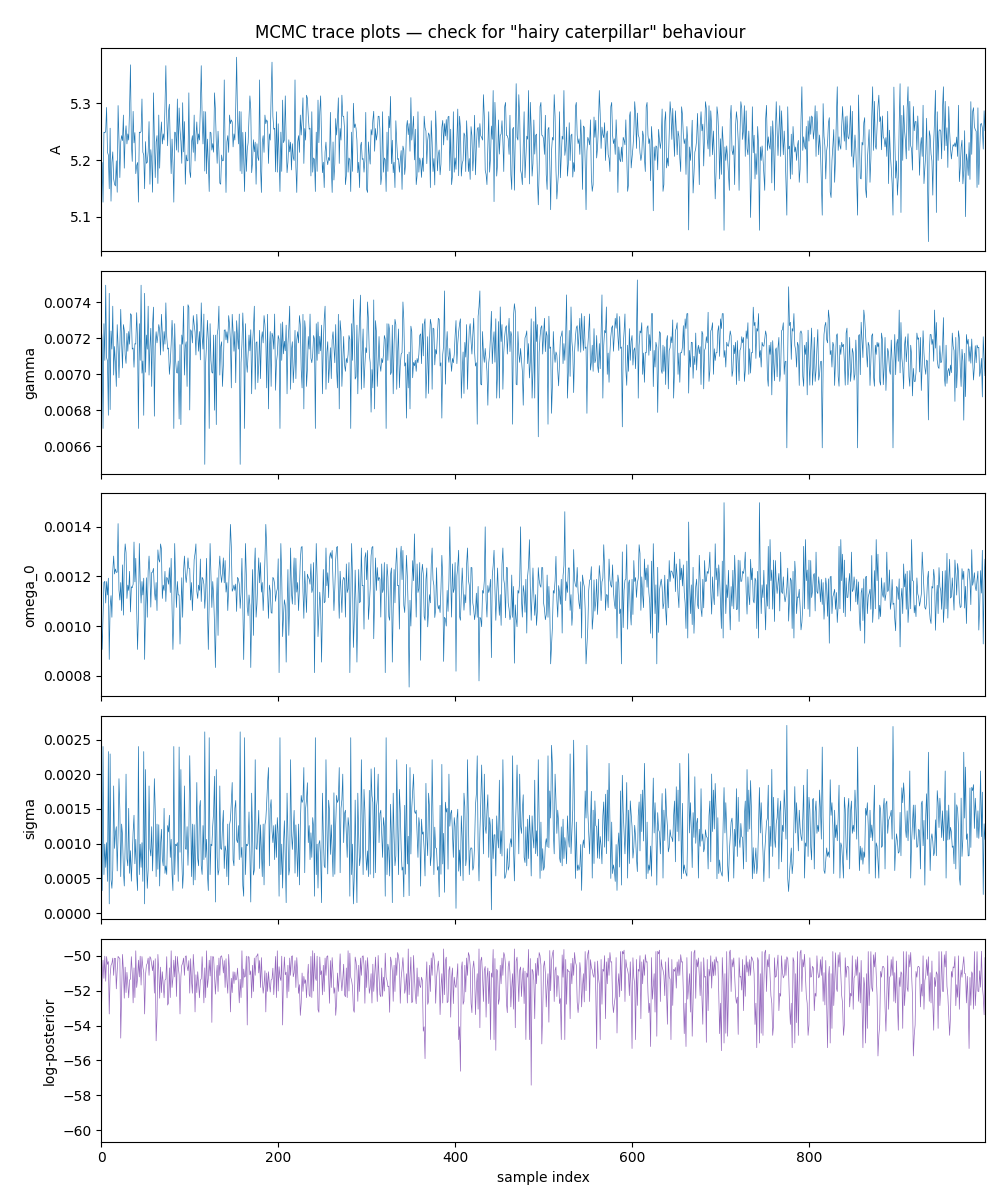

In [10]:
draws = result['draws']
logp = result['logp']
if callable(logp):
    _, logp = logp()
    logp = logp.flatten()
name_to_col = {name: idx for idx, name in enumerate(result['param_names'])}


def column_for(parameter):
    return draws[:, name_to_col[parameter.unique_name]]


fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

# Trace plots for each parameter
for ax, (label, par) in zip(
    axes[:4],
    (('A', A), ('gamma', gamma), ('omega_0', omega_0), ('sigma', sigma)),
):
    ax.plot(column_for(par), lw=0.5)
    ax.set_ylabel(label)
    ax.set_xlim(0, len(draws) - 1)

# Log-posterior trace
axes[4].plot(logp, lw=0.5, color='C4')
axes[4].set_ylabel('log-posterior')
axes[4].set_xlabel('sample index')

fig.suptitle('MCMC trace plots — check for "hairy caterpillar" behaviour')
fig.tight_layout()
plt.show()

## Exercise 5: posterior summaries

Summarise each marginal posterior by its **median** and the 16th/84th percentiles, which together give an asymmetric 68% credible interval. Compare these with the MLE values you obtained in Exercise 2.

```{note}
**Why might the Bayesian median differ from the MLE?** The MLE finds the single point that maximises the likelihood, while the Bayesian median is the central value of the *posterior* &mdash; which also accounts for the prior $p(\theta)$. If a parameter's posterior is skewed (asymmetric), the median and the mode (which approximates the MLE) will not coincide. The table below shows both so you can spot any such differences.
```

Note that the columns of `result['draws']` are ordered by `result['param_names']` (which use the parameters' `unique_name`), so it is worth building a small helper to look up a column by friendly name.

**Solution:**

In [11]:
summary_rows = []
for label, par in (('A', A), ('gamma', gamma), ('omega_0', omega_0), ('sigma', sigma)):
    col = column_for(par)
    lo, med, hi = np.percentile(col, [16, 50, 84])
    summary_rows.append((label, med, med - lo, hi - med, par.value))

print(f'{"param":<8s} {"median":>12s} {"-1σ":>12s} {"+1σ":>12s} {"MLE":>12s}')
for label, med, minus, plus, mle in summary_rows:
    print(f'{label:<8s} {med:12.4g} {minus:12.4g} {plus:12.4g} {mle:12.4g}')

param          median          -1σ          +1σ          MLE
A               5.231      0.05272      0.04595        5.216
gamma        0.007143    0.0001554    0.0001259     0.007013
omega_0      0.001152    0.0001038    9.494e-05     0.001344
sigma        0.001125    0.0005062    0.0005102    0.0004208


## Exercise 6: visualise the joint posterior

Marginal summaries hide correlations between parameters. A *corner plot* (a triangular grid of pairwise scatter plots and 1-D histograms) is the standard way to display them. Below we build one with plain `matplotlib`; if you have the [`corner`](https://corner.readthedocs.io/) package installed it will produce a publication-quality version with a single call.

**Solution:**

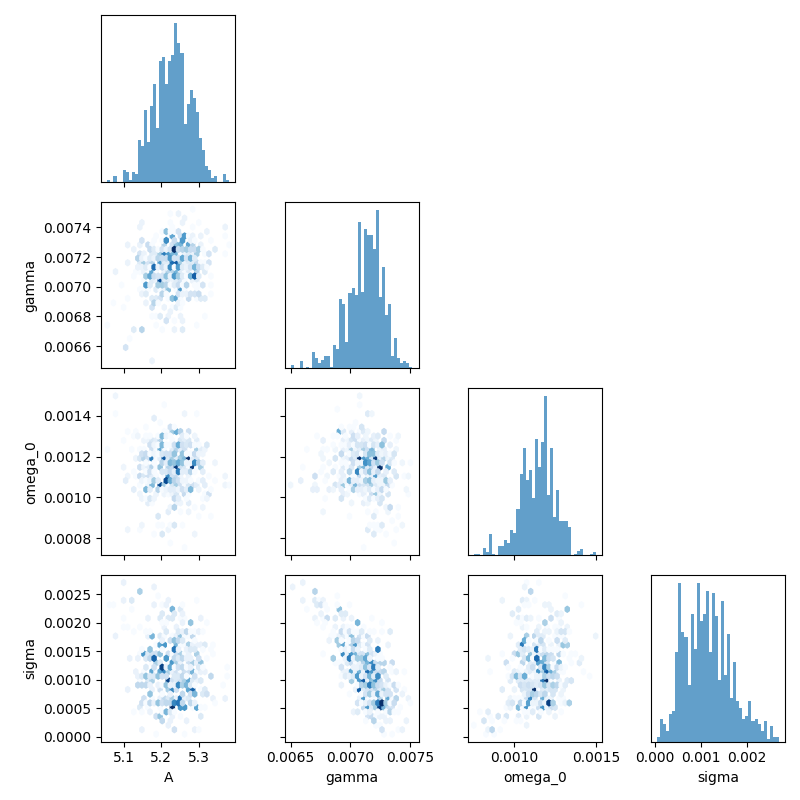

In [12]:
labels = ['A', 'gamma', 'omega_0', 'sigma']
cols = np.column_stack([column_for(p) for p in (A, gamma, omega_0, sigma)])
n = len(labels)

fig, axes = plt.subplots(n, n, figsize=(8, 8))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if j > i:
            ax.set_visible(False)
            continue
        if i == j:
            ax.hist(cols[:, i], bins=40, color='C0', histtype='stepfilled', alpha=0.7)
            ax.set_yticks([])
        else:
            ax.hexbin(cols[:, j], cols[:, i], gridsize=30, cmap='Blues', mincnt=1)
        if i == n - 1:
            ax.set_xlabel(labels[j])
        else:
            ax.set_xticklabels([])
        if j == 0 and i != 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
fig.tight_layout()
plt.show()

## Exercise 7: posterior-predictive band

One of the practical benefits of having the full posterior in hand is that it is trivial to propagate the uncertainty in the parameters through to predictions of the model. We pick a few hundred random draws, evaluate the model at each, and plot the resulting envelope alongside the data.

**Solution:**

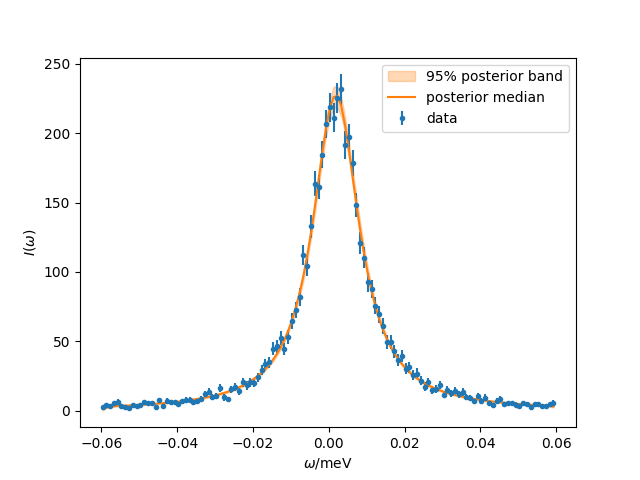

In [13]:
rng = np.random.default_rng(seed=0)
n_draws = 300
indices = rng.choice(draws.shape[0], size=n_draws, replace=False)

predictions = np.empty((n_draws, omega.size))
saved = {p.unique_name: p.value for p in (A, gamma, omega_0, sigma)}
try:
    for k, idx in enumerate(indices):
        A.value = draws[idx, name_to_col[A.unique_name]]
        gamma.value = draws[idx, name_to_col[gamma.unique_name]]
        omega_0.value = draws[idx, name_to_col[omega_0.unique_name]]
        sigma.value = draws[idx, name_to_col[sigma.unique_name]]
        predictions[k] = intensity(omega)
finally:
    for p in (A, gamma, omega_0, sigma):
        p.value = saved[p.unique_name]

lo = np.percentile(predictions, 2.5, axis=0)
hi = np.percentile(predictions, 97.5, axis=0)
mid = np.percentile(predictions, 50, axis=0)

fig, ax = plt.subplots()
ax.errorbar(omega, intensity_obs, di, fmt='.', label='data')
ax.fill_between(omega, lo, hi, color='C1', alpha=0.3, label='95% posterior band')
ax.plot(omega, mid, '-', color='C1', label='posterior median')
ax.set(xlabel='$\\omega$/meV', ylabel='$I(\\omega)$')
ax.legend()
plt.show()

## What next?

A few things to try as further exercises:

- Tighten or widen the `min`/`max` bounds on one of the parameters and see how the posterior reacts. This is the simplest possible *prior-sensitivity* analysis.
- Use the `chains` argument to `sample` to increase the DREAM population, e.g. `chains=10`, and check that the marginal histograms and trace plots are unchanged &mdash; a sign that the chains are sampling the same distribution.
- Pass a `progress_callback` to `sample` to monitor the sampler in real time &mdash; the same callback protocol used by the classical fitters works during MCMC (with `payload['sampling']` set to `True`).
- Inspect `result['state']` directly; the BUMPS [`MCMCDraw`](https://bumps.readthedocs.io/en/latest/api/bumps.dream.html) object exposes additional diagnostics such as per-chain log-posteriors, autocorrelation estimates, and the Gelman-Rubin $\hat{R}$ statistic for formal convergence assessment.